In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahragheb/all-autoimmune-disorder-10k")

print("Path to dataset files:", path)

100%|██████████| 4.92M/4.92M [00:00<00:00, 50.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdullahragheb/all-autoimmune-disorder-10k/versions/5


In [10]:
import os

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['Complete_Updated_Autoimmune_Disorder_Dataset2.csv', 'Autoimmune_Disorder_10k_with_All_Disorders.csv', 'Comprehensive_Autoimmune_Disorder_Dataset.csv', 'Complete_Updated_Autoimmune_Disorder_Dataset.csv', 'Final_Balanced_Autoimmune_Disorder_Dataset.csv']


In [11]:
import pandas as pd

df = pd.read_csv(path + "/Autoimmune_Disorder_10k_with_All_Disorders.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (12500, 79)


,Patient_ID,Age,Gender,Diagnosis,Sickness_Duration_Months,RBC_Count,Hemoglobin,Hematocrit,MCV,MCH,...,Anti_TIF1,Anti_epidermal_basement_membrane_IgA,Anti_OmpC,pANCA,Anti_tissue_transglutaminase,anti_Scl_70,Anti_Mi2,Anti_parietal_cell,Progesterone_antibodies,Anti_Sm
0,1,65,Female,Linear IgA disease,26,3.54,13.18,44.35,99.85,31.80,...,0,1,0,0,0,0,0,0,0,0
1,2,61,Male,Dermatomyositis,106,4.97,14.73,42.39,94.86,29.94,...,1,0,0,0,0,0,1,0,0,0
2,3,42,Male,Ord's thyroiditis,6,3.91,13.66,42.41,88.26,29.43,...,0,0,0,0,0,0,0,0,0,0
3,4,45,Female,Restless legs syndrome,11,4.57,14.96,40.10,85.95,27.42,...,0,0,0,0,0,0,0,0,0,0
4,5,78,Female,Autoimmune polyendocrine syndrome type 2 (APS2),30,4.88,11.21,37.58,93.16,29.87,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Check dataset information
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 79 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            12500 non-null  int64  
 1   Age                                   12500 non-null  int64  
 2   Gender                                12500 non-null  object 
 3   Diagnosis                             12500 non-null  object 
 4   Sickness_Duration_Months              12500 non-null  int64  
 5   RBC_Count                             12500 non-null  float64
 6   Hemoglobin                            12500 non-null  float64
 7   Hematocrit                            12500 non-null  float64
 8   MCV                                   12500 non-null  float64
 9   MCH                                   12500 non-null  float64
 10  MCHC                                  12500 non-null  float64

In [13]:
# Show only columns that contain missing values

missing = df.isnull().sum()

missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

Columns with missing values:
Anti-dsDNA           2500
Anti-Sm              2500
Rheumatoid factor    2500
ACPA                 2500
Anti-TPO             2500
Anti-Tg              2500
Anti-SMA             2500
dtype: int64


In [14]:
# Find numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing numerical values with median
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

            print("Missing numerical values filled.")

Missing numerical values filled.
Missing numerical values filled.
Missing numerical values filled.
Missing numerical values filled.
Missing numerical values filled.
Missing numerical values filled.
Missing numerical values filled.


In [15]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

print("\nDataset shape:", df.shape)

Total missing values: 0
Total duplicate rows: 0

Dataset shape: (12500, 79)


In [16]:
# Remove unnecessary spaces from text columns
df["Gender"] = df["Gender"].str.strip()
df["Diagnosis"] = df["Diagnosis"].str.strip()

print("Text columns cleaned.")

Text columns cleaned.


In [17]:
# Save cleaned dataset
df.to_csv("Cleaned_Autoimmune_Disorder_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [18]:
# Check values in binary columns
binary_columns = df.columns[21:]

for col in binary_columns:
    print(col, df[col].unique())

ANA [1 0]
Esbach [1.5  1.76 2.49 0.75 0.76 2.93 2.42 1.9  2.85 1.38 2.78 0.8  1.4  0.63
 1.77 2.2  1.2  1.74 2.71 2.47 0.97 2.29 2.26 0.88 2.7  2.76 0.74 2.48
 2.38 2.28 2.61 1.45 0.6  2.63 2.92 1.59 1.44 0.79 1.7  1.01 1.31 1.18
 2.5  1.46 1.84 2.56 1.6  1.53 2.9  2.33 1.06 1.09 2.97 2.59 0.62 0.57
 1.83 2.1  2.62 0.91 0.92 1.35 2.68 0.89 1.93 0.72 2.13 1.16 1.36 1.62
 1.33 2.18 0.73 1.04 1.87 2.57 2.46 0.93 0.61 1.43 0.54 1.21 2.58 1.32
 0.68 2.06 2.89 2.45 1.55 2.77 2.17 1.48 1.72 0.85 2.25 0.7  0.58 1.51
 2.27 2.09 0.83 0.84 1.81 0.56 2.31 1.54 0.64 1.24 1.68 2.94 1.49 2.07
 1.75 1.42 1.65 1.27 0.52 1.47 1.17 1.56 1.07 1.61 2.11 2.39 2.6  1.99
 0.53 2.36 1.97 2.   2.66 2.65 2.32 1.34 2.44 1.82 2.12 1.88 2.24 1.05
 1.64 2.51 1.41 1.15 2.88 0.86 2.05 1.8  1.96 0.55 2.15 1.91 0.99 2.22
 1.94 1.67 2.91 0.81 2.87 0.29 1.28 0.65 1.03 2.75 1.11 3.   1.98 2.41
 0.59 0.51 2.67 0.87 2.99 2.04 2.96 2.8  2.69 2.74 2.81 1.14 1.3  2.82
 2.43 0.69 0.9  0.82 1.   1.73 2.95 0.95 2.14 2.34 2.21 2.72

In [19]:
# Check ACPA values and counts
print("ACPA value counts:")
print(df["ACPA"].value_counts())

print("\nAnti_tTG value counts:")
print(df["Anti_tTG"].value_counts())

ACPA value counts:
ACPA
1.0    5000
0.0    5000
0.5    2500
Name: count, dtype: int64

Anti_tTG value counts:
Anti_tTG
0    12500
Name: count, dtype: int64


In [20]:
# Remove column with no variation
df = df.drop(columns=["Anti_tTG"])

print("Anti_tTG column removed.")
print("New dataset shape:", df.shape)

Anti_tTG column removed.
New dataset shape: (12500, 78)


In [21]:
# Final cleaning verification

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nACPA values:")
print(df["ACPA"].value_counts())

Rows: 12500
Columns: 78
Missing values: 0
Duplicate rows: 0

ACPA values:
ACPA
1.0    5000
0.0    5000
0.5    2500
Name: count, dtype: int64


In [22]:
df.to_csv("Cleaned_Autoimmune_Disorder_Dataset.csv", index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [23]:
from google.colab import files

files.download("Cleaned_Autoimmune_Disorder_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Cleaned_Autoimmune_Disorder_Dataset.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Cleaned dataset loaded successfully!
Shape: (12500, 78)
Missing Values: 0
Duplicate Rows: 0


Plots and outliers for uncleaned data

In [36]:
df_uncleaned = pd.read_csv(path + "/Autoimmune_Disorder_10k_with_All_Disorders.csv")

print("Uncleaned dataset loaded successfully!")
print("Shape:", df_uncleaned.shape)
print("Missing Values:", df_uncleaned.isnull().sum().sum())
print("Duplicate Rows:", df_uncleaned.duplicated().sum())

Uncleaned dataset loaded successfully!
Shape: (12500, 79)
Missing Values: 17500
Duplicate Rows: 0


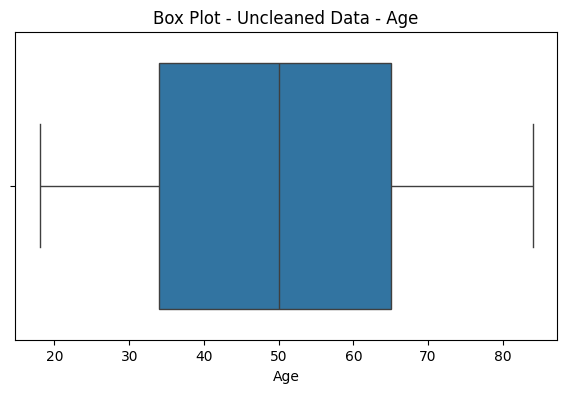

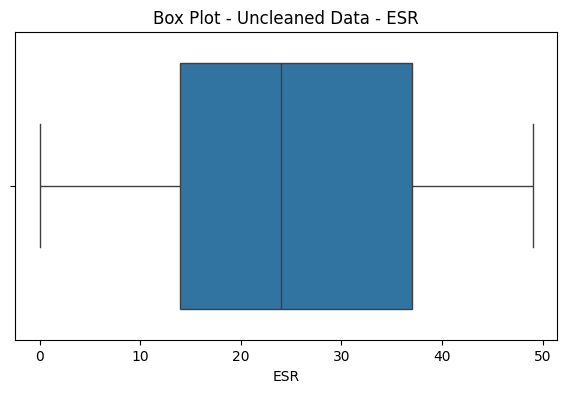

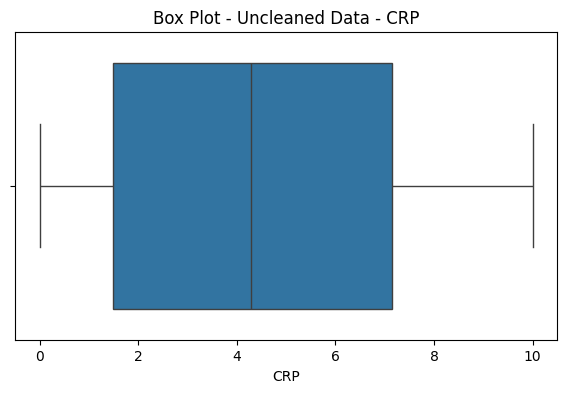

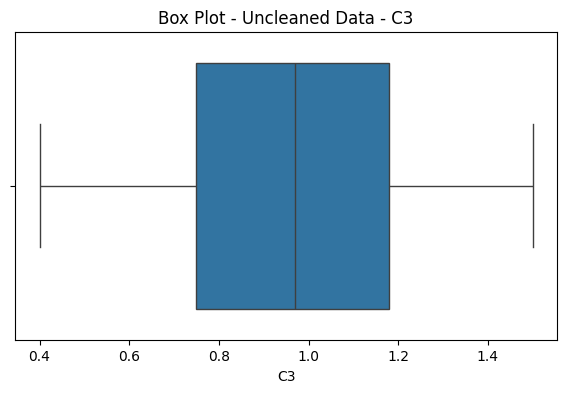

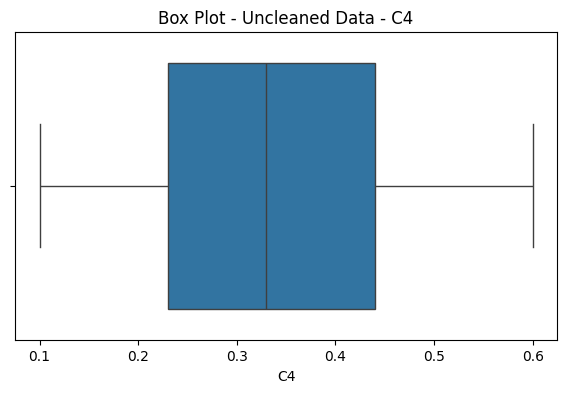

In [37]:
selected_columns = ["Age", "ESR", "CRP", "C3", "C4"]

for col in selected_columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df_uncleaned[col])
    plt.title("Box Plot - Uncleaned Data - " + col)
    plt.xlabel(col)
    plt.show()

In [38]:
iqr_uncleaned = {}

for col in selected_columns:
    Q1 = df_uncleaned[col].quantile(0.25)
    Q3 = df_uncleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_uncleaned[(df_uncleaned[col] < lower) | (df_uncleaned[col] > upper)]
    iqr_uncleaned[col] = len(outliers)
print("IQR Outliers - Uncleaned Data:")
print(iqr_uncleaned)

IQR Outliers - Uncleaned Data:
{'Age': 0, 'ESR': 0, 'CRP': 0, 'C3': 0, 'C4': 0}


In [39]:
z_uncleaned = {}

numeric_columns = df_uncleaned.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    values = df_uncleaned[col].dropna()
    z_scores = np.abs((values - values.mean()) / values.std())
    z_uncleaned[col] = (z_scores > 3).sum()

print("Z-Score Outliers - Uncleaned Data:")
print(z_uncleaned)

Z-Score Outliers - Uncleaned Data:
{'Patient_ID': np.int64(0), 'Age': np.int64(0), 'Sickness_Duration_Months': np.int64(0), 'RBC_Count': np.int64(0), 'Hemoglobin': np.int64(0), 'Hematocrit': np.int64(0), 'MCV': np.int64(0), 'MCH': np.int64(0), 'MCHC': np.int64(0), 'RDW': np.int64(0), 'Reticulocyte_Count': np.int64(0), 'WBC_Count': np.int64(0), 'Neutrophils': np.int64(0), 'Lymphocytes': np.int64(0), 'Monocytes': np.int64(0), 'Eosinophils': np.int64(0), 'Basophils': np.int64(0), 'PLT_Count': np.int64(0), 'MPV': np.int64(0), 'ANA': np.int64(0), 'Esbach': np.int64(0), 'MBL_Level': np.int64(0), 'ESR': np.int64(0), 'C3': np.int64(0), 'C4': np.int64(0), 'CRP': np.int64(0), 'Anti-dsDNA': np.int64(0), 'Anti-Sm': np.int64(0), 'Rheumatoid factor': np.int64(0), 'ACPA': np.int64(0), 'Anti-TPO': np.int64(0), 'Anti-Tg': np.int64(0), 'Anti-SMA': np.int64(0), 'Low-grade fever': np.int64(0), 'Fatigue or chronic tiredness': np.int64(0), 'Dizziness': np.int64(0), 'Weight loss': np.int64(0), 'Rashes and sk

Plot and outliers for cleaned data

In [25]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
Index(['Patient_ID', 'Age', 'Sickness_Duration_Months', 'RBC_Count',
       'Hemoglobin', 'Hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW',
       'Reticulocyte_Count', 'WBC_Count', 'Neutrophils', 'Lymphocytes',
       'Monocytes', 'Eosinophils', 'Basophils', 'PLT_Count', 'MPV', 'ANA',
       'Esbach', 'MBL_Level', 'ESR', 'C3', 'C4', 'CRP', 'Anti-dsDNA',
       'Anti-Sm', 'Rheumatoid factor', 'ACPA', 'Anti-TPO', 'Anti-Tg',
       'Anti-SMA', 'Low-grade fever', 'Fatigue or chronic tiredness',
       'Dizziness', 'Weight loss', 'Rashes and skin lesions',
       'Stiffness in the joints', 'Brittle hair or hair loss',
       'Dry eyes and/or mouth', 'General 'unwell' feeling', 'Joint pain',
       'Anti_dsDNA', 'Anti_enterocyte_antibodies', 'anti_LKM1', 'Anti_RNP',
       'ASCA', 'Anti_Ro_SSA', 'Anti_CBir1', 'Anti_BP230', 'DGP', 'Anti_BP180',
       'ASMA', 'Anti_IF', 'IgG_IgE_receptor', 'Anti_SRP', 'Anti_desmoglein_3',
       'Anti_La_SSB', 'Anti_Jo1', 'ANCA', 'anti_centromere

In [27]:
selected_columns = ["Age", "ESR", "CRP", "C3", "C4"]

for col in selected_columns:
    if col in df.columns:
            print(col, "found")
    else:
            print(col, "not found")

Age found
ESR found
CRP found
C3 found
C4 found


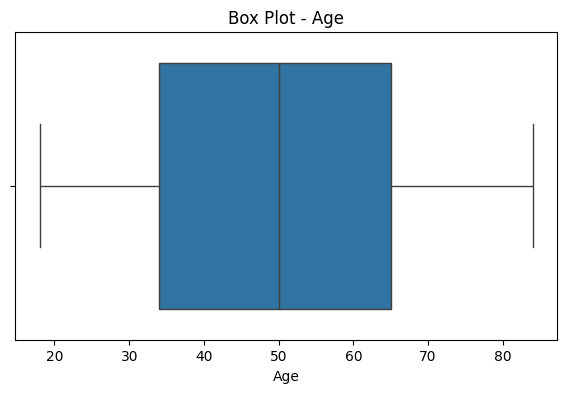

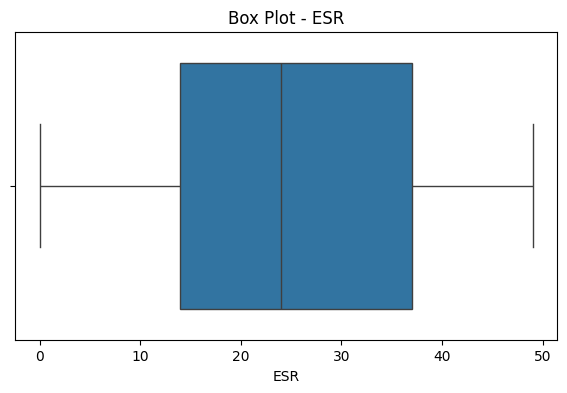

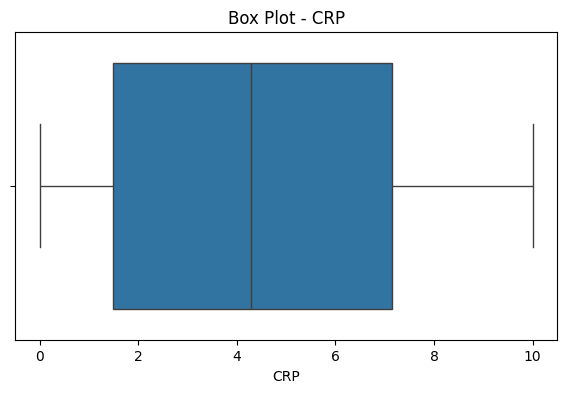

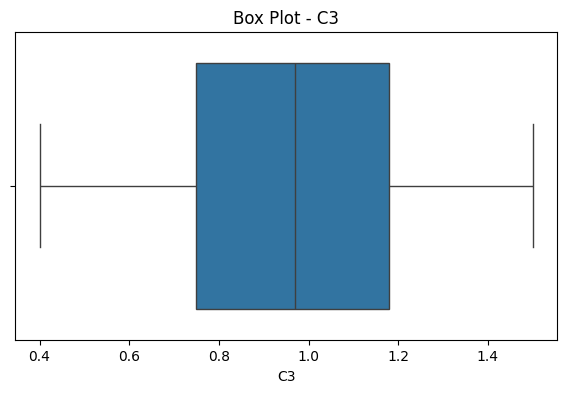

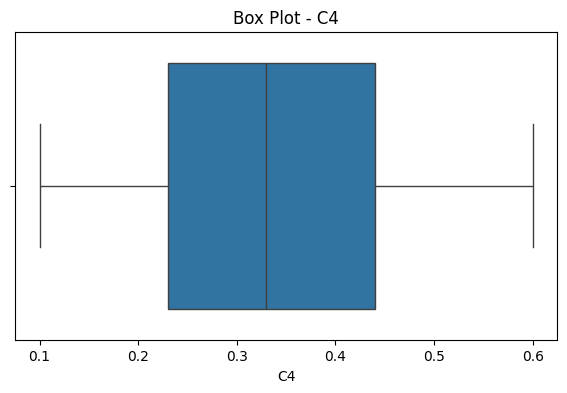

In [28]:
for col in selected_columns:
      plt.figure(figsize=(7,4))
      sns.boxplot(x=df[col])
      plt.title("Box Plot - " + col)
      plt.xlabel(col)
      plt.show()

In [29]:
iqr_outliers = {}

for col in selected_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    iqr_outliers[col] = len(outliers)
print("IQR Outlier Counts:")
print(iqr_outliers)

IQR Outlier Counts:
{'Age': 0, 'ESR': 0, 'CRP': 0, 'C3': 0, 'C4': 0}


In [31]:
iqr_table = pd.DataFrame(
      list(iqr_outliers.items()),
          columns=["Column", "IQR Outliers"]
          )

print(iqr_table)

  Column  IQR Outliers
0    Age             0
1    ESR             0
2    CRP             0
3     C3             0
4     C4             0


In [32]:
z_score_outliers = {}

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    if col in ["Patient ID", "Patient_ID"]:
            continue
    values = df[col].dropna()
    z_scores = np.abs((values - values.mean()) / values.std())
    z_score_outliers[col] = (z_scores > 3).sum()

print("Z-Score Outlier Counts:")
print(z_score_outliers)

Z-Score Outlier Counts:
{'Age': np.int64(0), 'Sickness_Duration_Months': np.int64(0), 'RBC_Count': np.int64(0), 'Hemoglobin': np.int64(0), 'Hematocrit': np.int64(0), 'MCV': np.int64(0), 'MCH': np.int64(0), 'MCHC': np.int64(0), 'RDW': np.int64(0), 'Reticulocyte_Count': np.int64(0), 'WBC_Count': np.int64(0), 'Neutrophils': np.int64(0), 'Lymphocytes': np.int64(0), 'Monocytes': np.int64(0), 'Eosinophils': np.int64(0), 'Basophils': np.int64(0), 'PLT_Count': np.int64(0), 'MPV': np.int64(0), 'ANA': np.int64(0), 'Esbach': np.int64(0), 'MBL_Level': np.int64(0), 'ESR': np.int64(0), 'C3': np.int64(0), 'C4': np.int64(0), 'CRP': np.int64(0), 'Anti-dsDNA': np.int64(0), 'Anti-Sm': np.int64(0), 'Rheumatoid factor': np.int64(0), 'ACPA': np.int64(0), 'Anti-TPO': np.int64(0), 'Anti-Tg': np.int64(0), 'Anti-SMA': np.int64(0), 'Low-grade fever': np.int64(0), 'Fatigue or chronic tiredness': np.int64(0), 'Dizziness': np.int64(0), 'Weight loss': np.int64(0), 'Rashes and skin lesions': np.int64(0), 'Stiffness i

In [33]:
z_score_table = pd.DataFrame(
      list(z_score_outliers.items()),
      columns=["Column", "Z-Score Outliers"]
 )

z_score_table = z_score_table.sort_values(
      by="Z-Score Outliers",
      ascending=False
)

print(z_score_table)

                          Column  Z-Score Outliers
51                    Anti_BP180               253
49                    Anti_BP230               253
69  Anti_tissue_transglutaminase               187
42                    Anti_dsDNA               185
74                       Anti_Sm               185
..                           ...               ...
15                     Basophils                 0
12                   Lymphocytes                 0
13                     Monocytes                 0
11                   Neutrophils                 0
26                       Anti-Sm                 0

[75 rows x 2 columns]


In [34]:
comparison = pd.DataFrame({
      "IQR Outliers": pd.Series(iqr_outliers),
      "Z-Score Outliers": pd.Series(z_score_outliers)
 })

comparison = comparison.fillna(0)

comparison = comparison.sort_values(
      by="Z-Score Outliers",
      ascending=False
)

print(comparison)

                              IQR Outliers  Z-Score Outliers
Anti_BP180                             0.0               253
Anti_BP230                             0.0               253
Anti_tissue_transglutaminase           0.0               187
Anti_dsDNA                             0.0               185
Anti_Sm                                0.0               185
...                                    ...               ...
RDW                                    0.0                 0
Weight loss                            0.0                 0
WBC_Count                              0.0                 0
Stiffness in the joints                0.0                 0
Sickness_Duration_Months               0.0                 0

[75 rows x 2 columns]


In [35]:
print("========== WEEK 3 CLEANING SPRINT ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Box Plot Outlier Detection: Completed")
print("IQR Outlier Detection: Completed")
print("Z-Score Outlier Detection: Completed")

========== WEEK 3 CLEANING SPRINT ==========
Rows: 12500
Columns: 78
Missing Values: 0
Duplicate Rows: 0
Box Plot Outlier Detection: Completed
IQR Outlier Detection: Completed
Z-Score Outlier Detection: Completed
